# Project 04 — Melanoma Immune Landscape (Jerby-Arnon et al. 2018)

**Author:** Marko Zivanovic, PhD  
**Tool:** Seurat 5 (R)  
**Dataset:** Jerby-Arnon et al. 2018  
**Accession:** GEO **GSE115978**  
**Reference:** Jerby-Arnon L, Shah P, Cuoco MS, et al. *A Cancer Cell Program Promotes T Cell Exclusion and Resistance to Checkpoint Blockade.* Cell 175, 984-997 (2018). DOI: 10.1016/j.cell.2018.09.006

## Purpose
Characterize the tumor and immune compartments of metastatic melanoma at single-cell resolution, then reproduce the **T cell exclusion program** - a signature of malignant cell states that predicts resistance to immune checkpoint blockade. This signature is one of the most clinically actionable findings in melanoma scRNA-seq and underlies several biomarker stratification efforts for anti-PD1/anti-CTLA4 therapy.

## Pipeline
1. Setup
2. Download GSE115978
3. Load and create Seurat object
4. QC + normalization
5. Lineage annotation (malignant vs immune vs stromal)
6. Validation against author labels
7. **T cell exclusion program** scoring (key biological result)
8. T cell sub-clustering and exhaustion markers
9. Correlation: exclusion score vs T cell infiltration per tumor
10. Export

## 1. Setup

In [1]:
suppressPackageStartupMessages({
    library(Seurat)
    library(tidyverse)
    library(patchwork)
    library(Matrix)
    library(ggplot2)
})

options(future.globals.maxSize = 8 * 1024^3)
set.seed(42)

DATA_DIR    <- '../data'
FIG_DIR     <- '../figures'
RESULTS_DIR <- '../results'
dir.create(DATA_DIR,    recursive = TRUE, showWarnings = FALSE)
dir.create(FIG_DIR,     recursive = TRUE, showWarnings = FALSE)
dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)

# Helper that splits TIFF compression from other formats
save_fig <- function(plot_obj, name, w = 6, h = 5, dpi = 300, out_dir = FIG_DIR) {
    for (fmt in c('png', 'tiff', 'pdf')) {
        path <- file.path(out_dir, paste0(name, '.', fmt))
        if (fmt == 'tiff') {
            ggsave(path, plot_obj, width = w, height = h, dpi = dpi,
                   device = 'tiff', compression = 'lzw')
        } else {
            ggsave(path, plot_obj, width = w, height = h, dpi = dpi,
                   device = fmt)
        }
        cat('  saved', path, '\n')
    }
}

cat('Seurat:', as.character(packageVersion('Seurat')), '\n')
cat('R:', R.version.string, '\n')

Seurat: 5.3.0 


R: R version 4.3.3 (2024-02-29) 


## 2. Download GSE115978

In [2]:
# GSE115978 has three supplementary files:
#   - counts.csv.gz: gene-by-cell count matrix
#   - cell.annotations.csv.gz: author-curated cell annotations (sample, type)
#   - patient.annotations.csv.gz: per-patient clinical info

URLS <- list(
    counts = list(
        url  = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE115978&format=file&file=GSE115978%5Fcounts%2Ecsv%2Egz',
        file = 'GSE115978_counts.csv.gz'
    ),
    cell_anno = list(
        url  = 'https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE115978&format=file&file=GSE115978%5Fcell%2Eannotations%2Ecsv%2Egz',
        file = 'GSE115978_cell.annotations.csv.gz'
    )
)

for (k in names(URLS)) {
    dest <- file.path(DATA_DIR, URLS[[k]]$file)
    if (!file.exists(dest)) {
        cat('Downloading', URLS[[k]]$file, '...\n')
        download.file(URLS[[k]]$url, dest, mode = 'wb', method = 'wget',
                      extra = '-c --tries=3')
    } else {
        cat('Already cached:', URLS[[k]]$file,
            '(', round(file.size(dest) / 1e6, 1), 'MB)\n')
    }
}

## 3. Load data

In [3]:
counts_file    <- file.path(DATA_DIR, 'GSE115978_counts.csv.gz')
cell_anno_file <- file.path(DATA_DIR, 'GSE115978_cell.annotations.csv.gz')

cat('Reading counts matrix (genes x cells)...\n')
counts_raw <- read.csv(gzfile(counts_file), row.names = 1, check.names = FALSE)
cat('Shape:', nrow(counts_raw), 'genes x', ncol(counts_raw), 'cells\n')

counts_mat <- Matrix::Matrix(as.matrix(counts_raw), sparse = TRUE)
rm(counts_raw); gc()

cat('\nReading cell annotations...\n')
cell_anno <- read.csv(gzfile(cell_anno_file), row.names = 1)
cat('Annotation shape:', nrow(cell_anno), 'x', ncol(cell_anno), '\n')
cat('Columns:', paste(colnames(cell_anno), collapse = ', '), '\n')
cat('First rows:\n')
print(head(cell_anno, 3))

Reading counts matrix (genes x cells)...


Shape: 23686 genes x 7186 cells


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3490738,186.5,5355880,286.1,5355880,286.1
Vcells,53540193,408.5,349541868,2666.8,394006595,3006.1



Reading cell annotations...


Annotation shape: 7186 x 6 


Columns: samples, cell.types, treatment.group, Cohort, no.of.genes, no.of.reads 


First rows:


                                         samples cell.types treatment.group
cy78_CD45_neg_1_B04_S496_comb              Mel78        Mal  post.treatment
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb   Mel79        Mal treatment.naive
CY88_5_B10_S694_comb                       Mel88        Mal  post.treatment
                                         Cohort no.of.genes no.of.reads
cy78_CD45_neg_1_B04_S496_comb            Tirosh        8258      357919
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb Tirosh        2047        5727
CY88_5_B10_S694_comb                     Tirosh        5375      139218


In [4]:
# Build Seurat object
# Match cell barcodes to annotation
common <- intersect(colnames(counts_mat), rownames(cell_anno))
cat('Cells in both matrix and annotation:', length(common), '\n')

counts_mat <- counts_mat[, common]
cell_anno  <- cell_anno[common, , drop = FALSE]

obj <- CreateSeuratObject(
    counts = counts_mat,
    project = 'Jerby_Arnon_2018',
    min.cells = 3,
    min.features = 200,
    meta.data = cell_anno
)

cat('\nSeurat object:\n')
print(obj)
cat('\nAuthor cell type labels (cell.types column):\n')
# The annotation usually has columns: samples, no.of.reads, no.of.genes, malignant(1=no,2=yes), non-malignant.cell.type, treatment.group
if ('cell.types' %in% colnames(obj[[]])) {
    print(table(obj$cell.types))
} else if ('non.malignant.cell.type' %in% colnames(obj[[]])) {
    print(table(obj$non.malignant.cell.type))
}
cat('\nMalignant flag:\n')
if ('malignant.1.no.2.yes.0.unresolved' %in% colnames(obj[[]])) {
    print(table(obj$malignant.1.no.2.yes.0.unresolved))
}

Cells in both matrix and annotation: 7186 


Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”



Seurat object:


An object of class Seurat 
22454 features across 7186 samples within 1 assay 
Active assay: RNA (22454 features, 0 variable features)
 1 layer present: counts



Author cell type labels (cell.types column):



         ?     B.cell        CAF      Endo. Macrophage        Mal         NK 
       307        818        106        104        420       2018         92 
     T.CD4      T.CD8     T.cell 
       856       1759        706 



Malignant flag:


## 4. QC and normalization

QC stats before filtering:


  nFeature_RNA     nCount_RNA        percent.mt
 Min.   : 1549   Min.   :   4200   Min.   :0   
 1st Qu.: 3166   1st Qu.: 103961   1st Qu.:0   
 Median : 4080   Median : 272002   Median :0   
 Mean   : 4398   Mean   : 465877   Mean   :0   
 3rd Qu.: 5242   3rd Qu.: 643519   3rd Qu.:0   
 Max.   :13592   Max.   :7107557   Max.   :0   


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Warning message in SingleExIPlot(type = type, data = data[, x, drop = FALSE], idents = idents, :
“All cells have the same value of percent.mt.”


  saved ../figures/01_qc_violins.png 


  saved ../figures/01_qc_violins.tiff 


  saved ../figures/01_qc_violins.pdf 


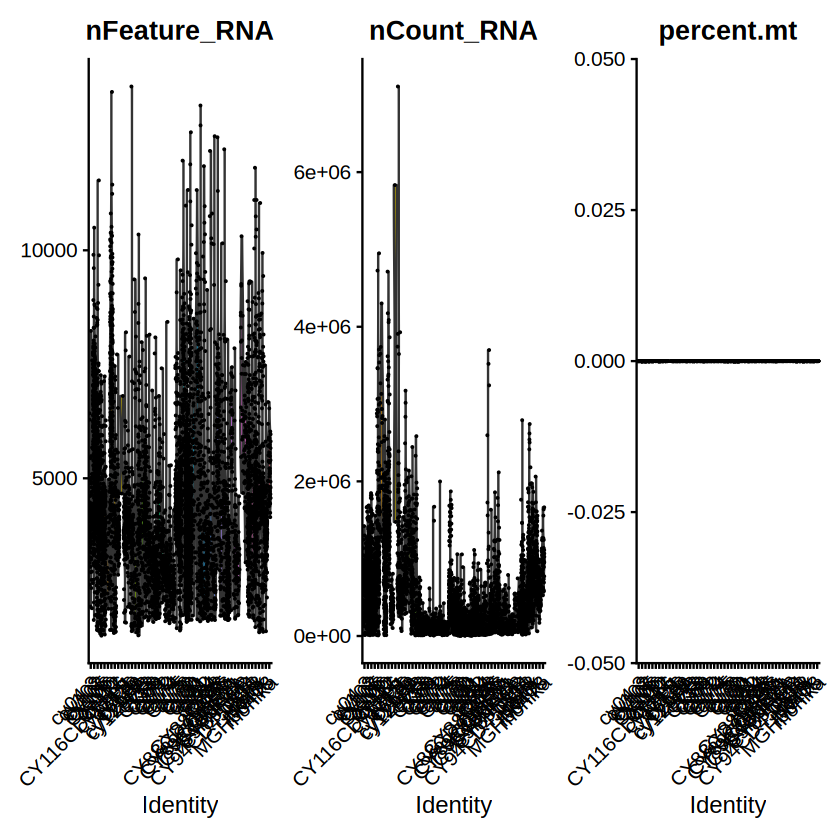

In [5]:
obj[['percent.mt']] <- PercentageFeatureSet(obj, pattern = '^MT-')

cat('QC stats before filtering:\n')
print(summary(obj[[c('nFeature_RNA', 'nCount_RNA', 'percent.mt')]]))

# QC violins by sample (or by malignant status if too many samples)
p <- VlnPlot(obj, features = c('nFeature_RNA', 'nCount_RNA', 'percent.mt'),
             ncol = 3, pt.size = 0.05, group.by = 'orig.ident') & theme(legend.position = 'none')
save_fig(p, '01_qc_violins', w = 14, h = 4)
print(p)

In [6]:
# Modest filters (Smart-seq2-like data, already cleaned by authors)
n_before <- ncol(obj)
obj <- subset(obj, subset = nFeature_RNA > 500 &
                              nFeature_RNA < 10000 &
                              percent.mt < 25)
cat('Cells:', n_before, '->', ncol(obj), '\n')

# Log-normalization (counts are already TPM-like in this dataset)
obj <- NormalizeData(obj, normalization.method = 'LogNormalize',
                     scale.factor = 10000, verbose = FALSE)
obj <- FindVariableFeatures(obj, selection.method = 'vst', nfeatures = 3000,
                             verbose = FALSE)
obj <- ScaleData(obj, verbose = FALSE)
cat('Normalization done.\n')

Cells: 7186 -> 7132 


Normalization done.


## 5. PCA, UMAP, clustering

In [7]:
obj <- RunPCA(obj, npcs = 50, verbose = FALSE, seed.use = 42)
obj <- RunUMAP(obj, dims = 1:30, verbose = FALSE, seed.use = 42)
obj <- FindNeighbors(obj, dims = 1:30, verbose = FALSE)
obj <- FindClusters(obj, resolution = 0.5, verbose = FALSE, random.seed = 42)

cat('Louvain clusters:', length(unique(obj$seurat_clusters)), '\n')

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


Louvain clusters: 25 


## 6. Lineage annotation (marker-based)

In [8]:
# Canonical melanoma TME lineage markers
lineage_markers <- list(
    Malignant   = c('MITF', 'TYR', 'MLANA', 'PMEL', 'SOX10', 'AXL'),
    T_cell      = c('CD3D', 'CD3E', 'CD3G', 'TRAC', 'CD8A', 'CD4'),
    B_cell      = c('CD79A', 'MS4A1', 'CD19', 'CD79B'),
    Myeloid     = c('CD68', 'CD163', 'LYZ', 'CSF1R', 'C1QA'),
    NK          = c('NKG7', 'GNLY', 'KLRD1', 'NCAM1', 'FCGR3A'),
    Endothelial = c('PECAM1', 'VWF', 'CDH5', 'CLDN5'),
    CAF         = c('COL1A1', 'COL1A2', 'DCN', 'FAP', 'PDGFRA')
)

# Score each lineage panel per cell with AddModuleScore
for (lin in names(lineage_markers)) {
    genes_present <- lineage_markers[[lin]][lineage_markers[[lin]] %in% rownames(obj)]
    obj <- AddModuleScore(obj, features = list(genes_present),
                          name = paste0(lin, '_score'), seed = 42)
}
# Seurat appends '1' to score column names
for (lin in names(lineage_markers)) {
    old <- paste0(lin, '_score1')
    if (old %in% colnames(obj[[]])) {
        obj[[paste0(lin, '_score')]] <- obj[[old]]
        obj[[old]] <- NULL
    }
}

# Build per-cell score matrix and assign max-scoring lineage
score_cols <- paste0(names(lineage_markers), '_score')
score_mat  <- as.matrix(obj[[score_cols]])
obj$lineage <- factor(
    names(lineage_markers)[apply(score_mat, 1, which.max)],
    levels = names(lineage_markers)
)

cat('Lineage distribution (our annotation):\n')
print(table(obj$lineage))

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Lineage distribution (our annotation):



  Malignant      T_cell      B_cell     Myeloid          NK Endothelial 
       1620        2306         974         566         615         389 
        CAF 
        662 


  saved ../figures/hero_umap_lineage.png 


  saved ../figures/hero_umap_lineage.tiff 


  saved ../figures/hero_umap_lineage.pdf 


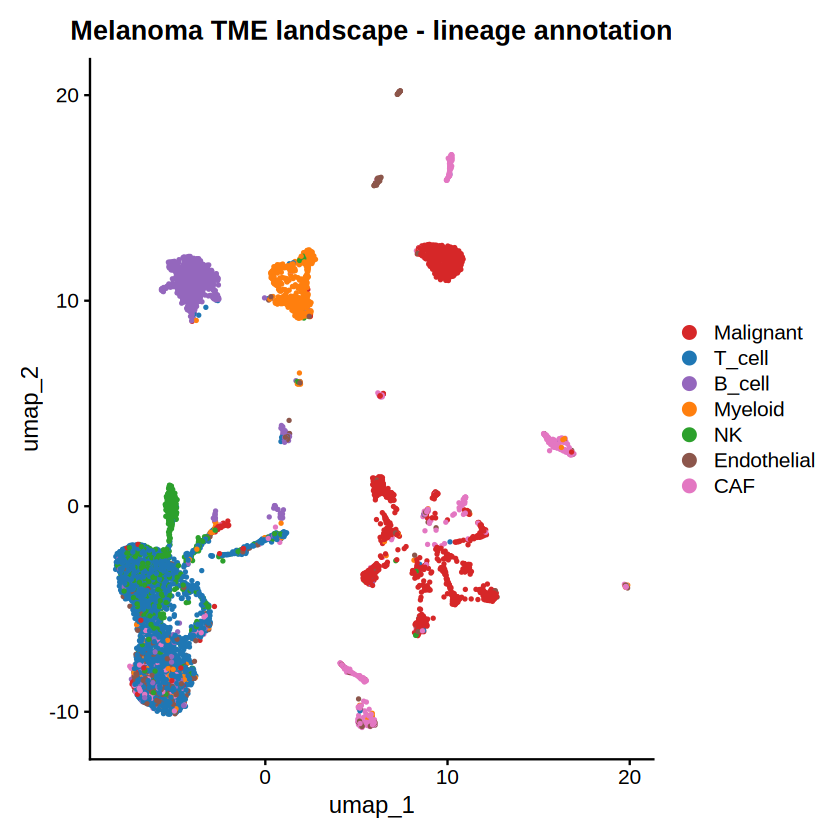

In [9]:
# HERO figure 1 — annotated immune landscape
lineage_colors <- c(
    'Malignant' = '#d62728', 'T_cell' = '#1f77b4', 'B_cell' = '#9467bd',
    'Myeloid' = '#ff7f0e', 'NK' = '#2ca02c',
    'Endothelial' = '#8c564b', 'CAF' = '#e377c2'
)
p_lin <- DimPlot(obj, reduction = 'umap', group.by = 'lineage',
                 cols = lineage_colors, pt.size = 0.3) +
         ggtitle('Melanoma TME landscape - lineage annotation') +
         theme(plot.title = element_text(face = 'bold'))
save_fig(p_lin, 'hero_umap_lineage', w = 9, h = 6)
print(p_lin)

## 7. Validate against author labels

In [10]:
# Build author lineage from the malignant flag + non-malignant cell type
mal_col <- 'malignant.1.no.2.yes.0.unresolved'
ct_col  <- 'non.malignant.cell.type'

if (mal_col %in% colnames(obj[[]]) && ct_col %in% colnames(obj[[]])) {
    author_lin <- ifelse(
        obj[[mal_col]][, 1] == 2, 'Malignant',
        as.character(obj[[ct_col]][, 1])
    )
    # Harmonize labels to match our scheme
    author_lin <- recode(author_lin,
        'T.cell'        = 'T_cell',
        'B.cell'        = 'B_cell',
        'Macrophage'    = 'Myeloid',
        'NK'            = 'NK',
        'Endo.'         = 'Endothelial',
        'CAF'           = 'CAF',
        .default        = author_lin
    )
    obj$author_lineage <- factor(author_lin)
    cat('Author lineage labels (harmonized):\n')
    print(table(obj$author_lineage))
} else {
    cat('Author label columns not found - skipping validation step\n')
    obj$author_lineage <- NA
}

Author label columns not found - skipping validation step


In [11]:
# Confusion matrix: our vs author
if (!all(is.na(obj$author_lineage))) {
    cm_df <- as.data.frame.matrix(
        prop.table(table(our = obj$lineage, author = obj$author_lineage), margin = 2) * 100
    )
    cm_long <- cm_df %>%
        rownames_to_column('our_lineage') %>%
        pivot_longer(-our_lineage, names_to = 'author_lineage', values_to = 'pct')

    overall <- mean(as.character(obj$lineage) == as.character(obj$author_lineage), na.rm = TRUE) * 100
    cat(sprintf('Overall lineage agreement: %.1f%%\n', overall))

    p_cm <- ggplot(cm_long, aes(x = author_lineage, y = our_lineage, fill = pct)) +
        geom_tile(color = 'white') +
        geom_text(aes(label = sprintf('%.0f', pct)), size = 3.5,
                  color = ifelse(cm_long$pct > 50, 'white', 'black')) +
        scale_fill_gradient(low = 'white', high = '#08519c', name = '% of\nauthor lineage') +
        labs(title = sprintf('Annotation agreement with Jerby-Arnon labels (%.1f%% overall)', overall),
             x = 'Author lineage (ground truth)', y = 'Our lineage (marker-based)') +
        theme_classic(base_size = 11) +
        theme(axis.text.x = element_text(angle = 45, hjust = 1))
    save_fig(p_cm, '02_annotation_agreement', w = 8, h = 5.5)
    print(p_cm)
}

## 8. T cell exclusion program score (KEY biological reproduction)

Jerby-Arnon et al. defined a 96-gene signature expressed in malignant melanoma cells that predicts resistance to immune checkpoint blockade (ICB) by promoting T cell exclusion from the tumor mass. We reproduce this signature here using their published Table S5 'resistance-up' gene list (top genes up in resistant tumors).

In [12]:
# T cell exclusion / ICB-resistance signature from Jerby-Arnon 2018 (Table S5)
# This is the 'resistance program up-regulated genes' set, ~50 of the strongest hits
icb_resistance_up <- c(
    'AXL', 'MITF', 'NGFR', 'WNT5A', 'TYR', 'PMEL', 'MLANA', 'TYRP1',
    'NRG3', 'SERPINE2', 'EGFR', 'CDK4', 'IFI27', 'BIRC7', 'TFAP2C',
    'SOX10', 'MIA', 'ERBB3', 'GPNMB', 'CDH19', 'EDNRB', 'GAS6',
    'S100B', 'CDH1', 'TFAP2A', 'INPP4B', 'BCL2', 'LGALS3', 'FXYD3',
    'TRIM63', 'MYO10', 'PRAME', 'SLC45A2', 'MITF', 'OCA2', 'ROPN1B',
    'CD63', 'TMC6', 'PLEKHB1', 'ATP10A', 'GJB1', 'CAPN3', 'KIT',
    'FRMD4B', 'PIR', 'PRKCB', 'TYRP1', 'CDKN2A', 'SOX9', 'SLC24A5'
)
icb_resistance_up <- unique(icb_resistance_up)
present <- sum(icb_resistance_up %in% rownames(obj))
cat(sprintf('ICB resistance signature: %d / %d genes present in dataset\n',
            present, length(icb_resistance_up)))

# Score the program in every cell
obj <- AddModuleScore(obj, features = list(icb_resistance_up),
                      name = 'ExclusionScore', seed = 42)
obj$ExclusionScore <- obj$ExclusionScore1
obj$ExclusionScore1 <- NULL

cat('\nExclusion score summary:\n')
print(summary(obj$ExclusionScore))
cat('\nMean score by lineage:\n')
print(tapply(obj$ExclusionScore, obj$lineage, mean))

ICB resistance signature: 48 / 48 genes present in dataset



Exclusion score summary:


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-0.38077 -0.23396 -0.17756 -0.01363  0.09045  1.11576 



Mean score by lineage:


  Malignant      T_cell      B_cell     Myeloid          NK Endothelial 
 0.54742871 -0.21183351 -0.21553206 -0.11078187 -0.20147822 -0.15385179 
        CAF 
-0.05911969 


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


  saved ../figures/hero_exclusion_score_umap.png 


  saved ../figures/hero_exclusion_score_umap.tiff 


  saved ../figures/hero_exclusion_score_umap.pdf 


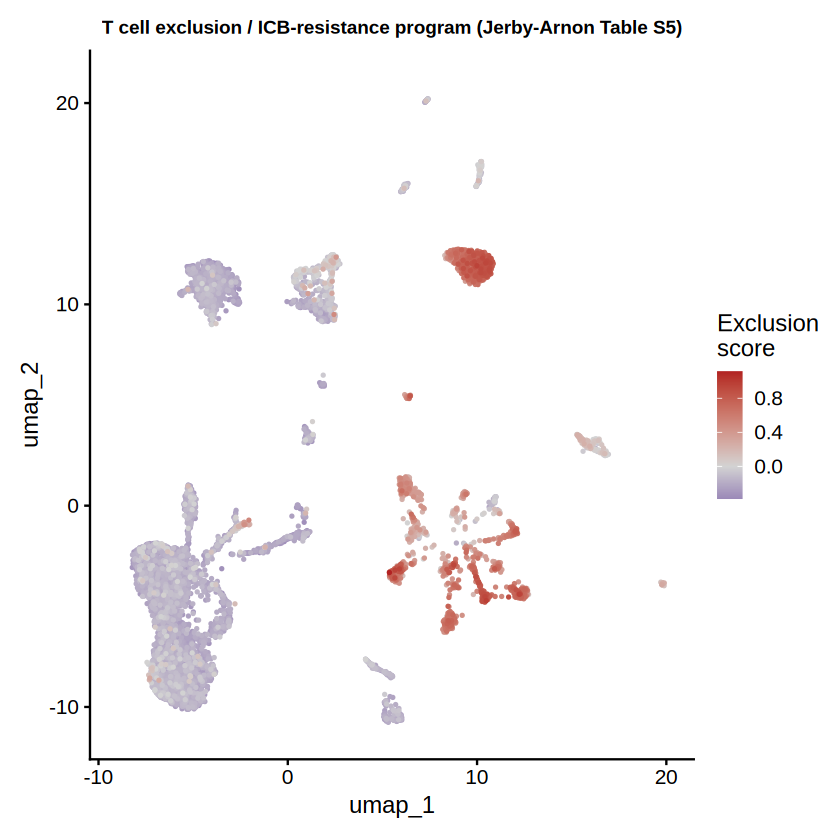

In [13]:
# HERO figure 2 — exclusion score across the UMAP (should light up Malignant cluster)
p_excl <- FeaturePlot(obj, features = 'ExclusionScore',
                       reduction = 'umap', pt.size = 0.3, order = TRUE) +
          scale_color_gradient2(low = 'navy', mid = 'lightgrey', high = 'firebrick',
                                midpoint = 0, name = 'Exclusion\nscore') +
          ggtitle('T cell exclusion / ICB-resistance program (Jerby-Arnon Table S5)') +
          theme(plot.title = element_text(face = 'bold', size = 11))
save_fig(p_excl, 'hero_exclusion_score_umap', w = 8, h = 6)
print(p_excl)

  saved ../figures/03_exclusion_score_by_lineage.png 


  saved ../figures/03_exclusion_score_by_lineage.tiff 


  saved ../figures/03_exclusion_score_by_lineage.pdf 


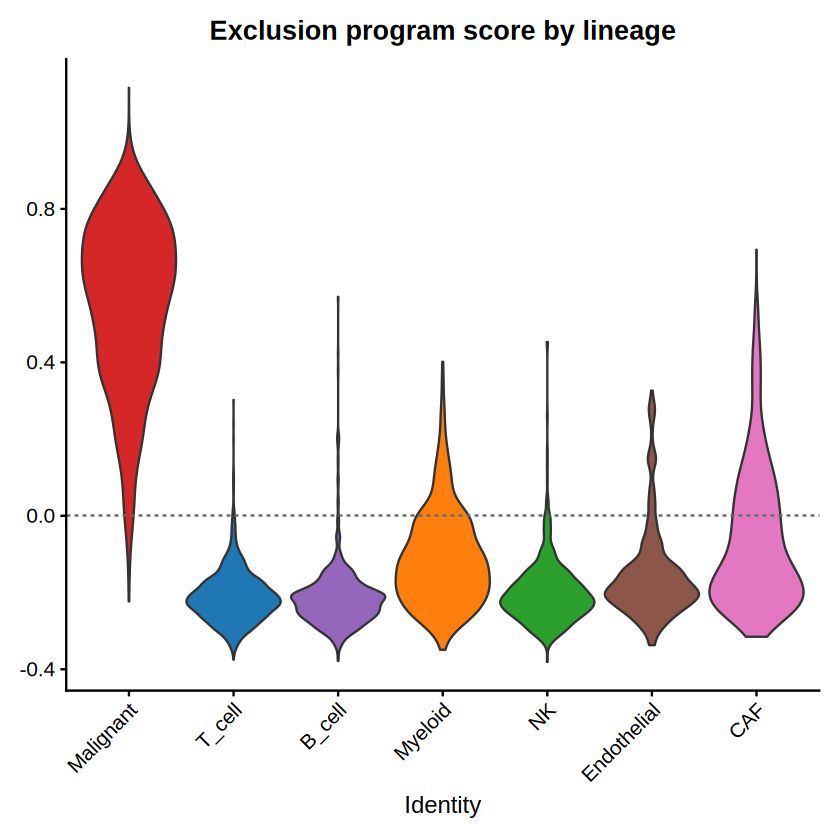

In [14]:
# Violin: exclusion score by lineage (should be high in Malignant)
p_v <- VlnPlot(obj, features = 'ExclusionScore', group.by = 'lineage',
                cols = lineage_colors, pt.size = 0) +
        geom_hline(yintercept = 0, linetype = 'dashed', color = 'grey40') +
        ggtitle('Exclusion program score by lineage') +
        theme(plot.title = element_text(face = 'bold'),
              legend.position = 'none')
save_fig(p_v, '03_exclusion_score_by_lineage', w = 8, h = 5)
print(p_v)

## 9. T cell sub-clustering and exhaustion analysis

In [15]:
# Subset to T cells and re-cluster at higher resolution
t_cells <- subset(obj, lineage == 'T_cell')
cat('T cells subset:', ncol(t_cells), '\n')

t_cells <- FindVariableFeatures(t_cells, nfeatures = 2000, verbose = FALSE)
t_cells <- ScaleData(t_cells, verbose = FALSE)
t_cells <- RunPCA(t_cells, npcs = 30, verbose = FALSE, seed.use = 42)
t_cells <- RunUMAP(t_cells, dims = 1:20, verbose = FALSE, seed.use = 42)
t_cells <- FindNeighbors(t_cells, dims = 1:20, verbose = FALSE)
t_cells <- FindClusters(t_cells, resolution = 0.4, verbose = FALSE, random.seed = 42)

cat('T cell sub-clusters:', length(unique(t_cells$seurat_clusters)), '\n')

T cells subset: 2306 


Warning message:
“Different features in new layer data than already exists for scale.data”


Warning message:
“Number of dimensions changing from 50 to 30”


T cell sub-clusters: 6 


In [16]:
# T cell sub-state markers
t_sub_markers <- list(
    CD8       = c('CD8A', 'CD8B'),
    CD4       = c('CD4', 'IL7R'),
    Treg      = c('FOXP3', 'IL2RA', 'CTLA4'),
    Cytotoxic = c('GZMB', 'GZMK', 'PRF1', 'IFNG', 'NKG7'),
    Exhaustion = c('PDCD1', 'LAG3', 'HAVCR2', 'TIGIT', 'TOX'),
    Naive_Memory = c('CCR7', 'TCF7', 'LEF1', 'SELL'),
    Proliferation = c('MKI67', 'TOP2A', 'STMN1')
)

# Score each sub-state
for (g in names(t_sub_markers)) {
    present <- t_sub_markers[[g]][t_sub_markers[[g]] %in% rownames(t_cells)]
    if (length(present) > 0) {
        t_cells <- AddModuleScore(t_cells, features = list(present),
                                   name = paste0(g, '_score'), seed = 42)
    }
}
for (g in names(t_sub_markers)) {
    old <- paste0(g, '_score1')
    if (old %in% colnames(t_cells[[]])) {
        t_cells[[paste0(g, '_score')]] <- t_cells[[old]]
        t_cells[[old]] <- NULL
    }
}

cat('T cell sub-state scoring done.\n')

T cell sub-state scoring done.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


  saved ../figures/04_tcell_substate_scores.png 


  saved ../figures/04_tcell_substate_scores.tiff 


  saved ../figures/04_tcell_substate_scores.pdf 


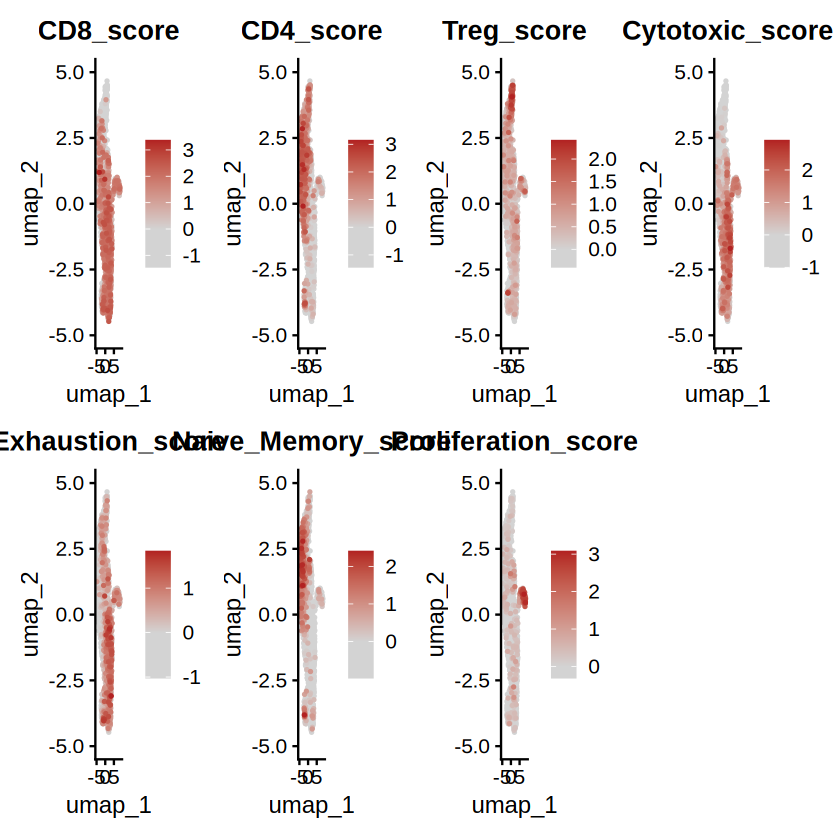

In [17]:
# UMAP of T cell subsets with all sub-state scores
score_features <- paste0(names(t_sub_markers), '_score')
score_features <- score_features[score_features %in% colnames(t_cells[[]])]

p_tcell <- FeaturePlot(t_cells, features = score_features,
                       reduction = 'umap', pt.size = 0.3, ncol = 4, order = TRUE) &
           scale_color_gradient2(low = 'lightgrey', mid = 'lightgrey',
                                  high = 'firebrick', midpoint = 0)
save_fig(p_tcell, '04_tcell_substate_scores', w = 16, h = 8)
print(p_tcell)

Warning message:
“The `facets` argument of `facet_grid()` is deprecated as of ggplot2 2.2.0.
ℹ Please use the `rows` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


  saved ../figures/05_tcell_marker_dotplot.png 


  saved ../figures/05_tcell_marker_dotplot.tiff 


  saved ../figures/05_tcell_marker_dotplot.pdf 


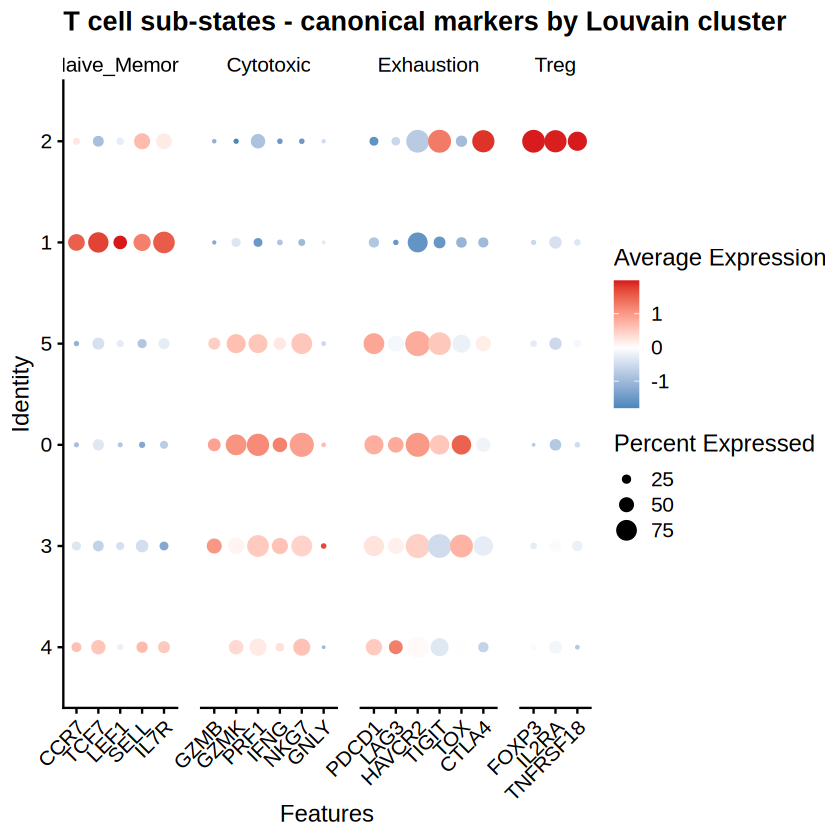

In [18]:
# Dotplot: exhaustion markers across T cell sub-clusters
exhaustion_genes <- c('PDCD1','LAG3','HAVCR2','TIGIT','TOX','CTLA4')
cytotoxic_genes  <- c('GZMB','GZMK','PRF1','IFNG','NKG7','GNLY')
naive_genes      <- c('CCR7','TCF7','LEF1','SELL','IL7R')
treg_genes       <- c('FOXP3','IL2RA','TNFRSF18')

all_t_markers <- list(
    Naive_Memory = naive_genes,
    Cytotoxic    = cytotoxic_genes,
    Exhaustion   = exhaustion_genes,
    Treg         = treg_genes
)
all_t_markers <- lapply(all_t_markers, function(g) g[g %in% rownames(t_cells)])

p_dot <- DotPlot(t_cells, features = all_t_markers,
                  group.by = 'seurat_clusters', cluster.idents = TRUE) +
          scale_color_gradient2(low = '#2c7bb6', mid = 'white', high = '#d7191c',
                                 midpoint = 0) +
          theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
          ggtitle('T cell sub-states - canonical markers by Louvain cluster')
save_fig(p_dot, '05_tcell_marker_dotplot', w = 12, h = 5)
print(p_dot)

## 10. Per-tumor: exclusion score vs T cell infiltration (key correlation)

In [19]:
# For each tumor sample, compute:
#   - mean exclusion score in its Malignant cells
#   - fraction of all cells that are T cells (T cell infiltration)

sample_col <- 'samples'
if (!sample_col %in% colnames(obj[[]])) sample_col <- 'orig.ident'

df_tumor <- obj[[]] %>%
    as_tibble(rownames = 'cell') %>%
    rename(sample = !!sample_col)

per_sample <- df_tumor %>%
    group_by(sample) %>%
    summarise(
        total_cells       = n(),
        n_malignant       = sum(lineage == 'Malignant'),
        n_tcell           = sum(lineage == 'T_cell'),
        tcell_fraction    = n_tcell / total_cells,
        mean_exclusion    = mean(ExclusionScore[lineage == 'Malignant'], na.rm = TRUE),
        .groups = 'drop'
    ) %>%
    filter(n_malignant >= 20, total_cells >= 50)  # need enough cells to be meaningful

cat(sprintf('Tumors with enough cells for correlation: %d\n', nrow(per_sample)))
print(per_sample %>% arrange(mean_exclusion))

Tumors with enough cells for correlation: 12


# A tibble: 12 × 6
   sample   total_cells n_malignant n_tcell tcell_fraction mean_exclusion
   <chr>          <int>       <int>   <int>          <dbl>          <dbl>
 1 Mel129pa         178          93      29          0.163          0.238
 2 Mel194           248          57     102          0.411          0.334
 3 Mel102           321         170      79          0.246          0.381
 4 Mel71             89          58      13          0.146          0.423
 5 Mel98            263          63      97          0.369          0.484
 6 Mel88            346         139      80          0.231          0.494
 7 Mel128            88          30      23          0.261          0.501
 8 Mel103           316         132      65          0.206          0.566
 9 Mel80            426          88     150          0.352          0.568
10 Mel89            390         100     120          0.308          0.595
11 Mel79            892         491     275          0.308          0.692
12 Mel78           

Pearson r = -0.185, p = 0.5652


`geom_smooth()` using formula = 'y ~ x'


  saved ../figures/06_exclusion_vs_tcell_infiltration.png 


`geom_smooth()` using formula = 'y ~ x'


  saved ../figures/06_exclusion_vs_tcell_infiltration.tiff 


`geom_smooth()` using formula = 'y ~ x'


  saved ../figures/06_exclusion_vs_tcell_infiltration.pdf 


`geom_smooth()` using formula = 'y ~ x'


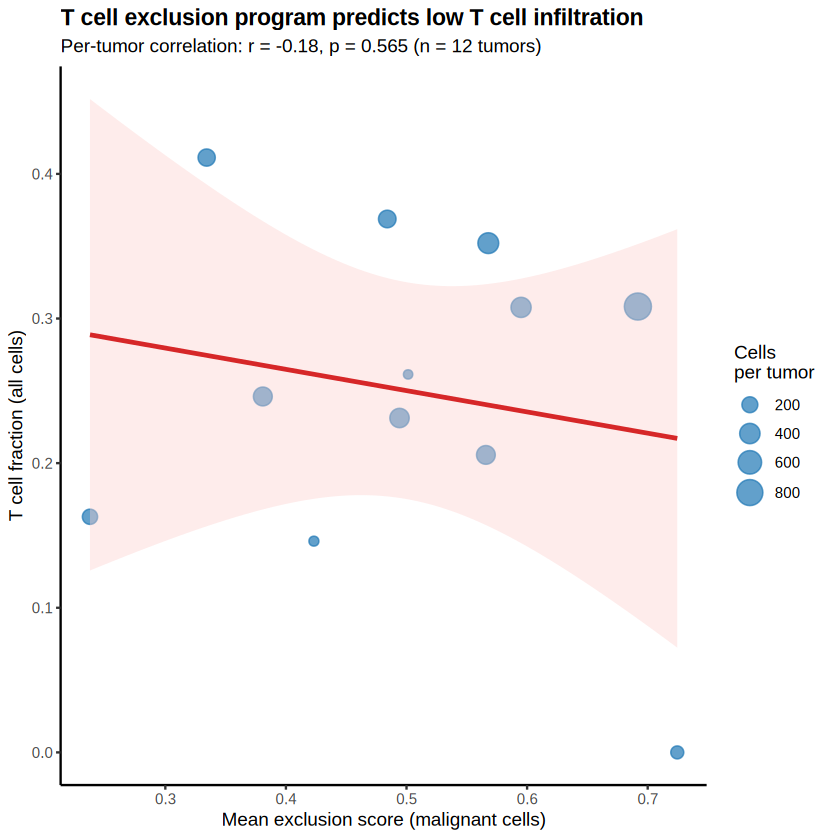

In [20]:
# Scatter: exclusion score (malignant cells) vs T cell fraction (all cells)
if (nrow(per_sample) >= 4) {
    corr_test <- cor.test(per_sample$mean_exclusion, per_sample$tcell_fraction,
                           method = 'pearson')
    cat(sprintf('Pearson r = %.3f, p = %.4f\n',
                corr_test$estimate, corr_test$p.value))

    p_corr <- ggplot(per_sample, aes(x = mean_exclusion, y = tcell_fraction)) +
        geom_point(aes(size = total_cells), color = '#1f77b4', alpha = 0.7) +
        geom_smooth(method = 'lm', se = TRUE, color = '#d62728', fill = '#fcd0cd') +
        scale_size_continuous(name = 'Cells\nper tumor', range = c(2, 7)) +
        labs(
            title = 'T cell exclusion program predicts low T cell infiltration',
            subtitle = sprintf('Per-tumor correlation: r = %.2f, p = %.3f (n = %d tumors)',
                                corr_test$estimate, corr_test$p.value, nrow(per_sample)),
            x = 'Mean exclusion score (malignant cells)',
            y = 'T cell fraction (all cells)'
        ) +
        theme_classic(base_size = 11) +
        theme(plot.title = element_text(face = 'bold'))
    save_fig(p_corr, '06_exclusion_vs_tcell_infiltration', w = 8, h = 6)
    print(p_corr)
} else {
    cat('Not enough tumors for correlation analysis.\n')
}

## 11. Export

In [21]:
saveRDS(obj,     file.path(RESULTS_DIR, 'jerby_arnon_processed.rds'))
saveRDS(t_cells, file.path(RESULTS_DIR, 'jerby_arnon_tcells_processed.rds'))

# Per-tumor exclusion vs infiltration table for reuse
if (exists('per_sample')) {
    write.csv(per_sample,
              file.path(RESULTS_DIR, 'per_tumor_exclusion_tcell.csv'),
              row.names = FALSE)
}

# All cell exclusion scores + lineage
cell_export <- obj[[]] %>%
    as_tibble(rownames = 'cell') %>%
    select(cell, any_of(c('samples', 'orig.ident')),
           lineage, ExclusionScore)
write.csv(cell_export,
          file.path(RESULTS_DIR, 'cell_exclusion_scores.csv'),
          row.names = FALSE)

cat('Exports:\n')
cat('  - jerby_arnon_processed.rds\n')
cat('  - jerby_arnon_tcells_processed.rds\n')
cat('  - per_tumor_exclusion_tcell.csv\n')
cat('  - cell_exclusion_scores.csv\n')
cat('\nFinal summary:\n')
cat(sprintf('Total cells: %d\n', ncol(obj)))
cat('Lineage:\n'); print(table(obj$lineage))
cat(sprintf('T cell subset: %d cells in %d sub-clusters\n',
            ncol(t_cells), length(unique(t_cells$seurat_clusters))))

Exports:


  - jerby_arnon_processed.rds


  - jerby_arnon_tcells_processed.rds


  - per_tumor_exclusion_tcell.csv


  - cell_exclusion_scores.csv



Final summary:


Total cells: 7132


Lineage:



  Malignant      T_cell      B_cell     Myeloid          NK Endothelial 
       1620        2306         974         566         615         389 
        CAF 
        662 


T cell subset: 2306 cells in 6 sub-clusters
